# Interpretabilidad del ensemble final · TFM Energía UCM

Reproduce las tablas y figuras de la discusión de explicatividad e interpretabilidad del informe (`docs/interpretabilidad/discusion_interpretabilidad_informe.md`) sobre el modelo final `ensemble_seleccion` de `data/gold/finales_v2_nucleo`.

Por defecto **lee los resultados ya calculados** y tarda segundos. Las figuras se dibujan con el mismo código que los scripts que generaron las del informe, se muestran en línea y se comparan píxel a píxel con los PNG del informe, **sin sobrescribirlos**. Junto a cada tabla se imprimen las cifras clave y se comprueba que aparecen, con el mismo redondeo, en el texto del informe.

| sección | qué se ve | resultados que lee | script de cálculo | figura del informe |
|---|---|---|---|---|
| 1 | permutación por grupos del sistema completo | `permutacion_ensemble*.csv` | `permutacion_ensemble.py` | `fig_permutacion_ensemble.png` (Figura X, `fig_permutacion_informe.py`) |
| 2 | SHAP del LightGBM, miembro de mayor peso | `shap_lgbm_grupos.csv`, `shap_lgbm_variables.csv`, `shap_lgbm_ganancia_*.csv` | `shap_lgbm.py`, `shap_lgbm_ganancia.py` | de apoyo: `fig_shap_lgbm.png` (descartada del informe) |
| 3 | precio portugués frente a español | `permutacion_pt_es_lgbm_test.csv`, `shap_lgbm_resumen.json` | `shap_lgbm.py` | — |
| 4 | contraste con el EDA | `shap_vs_eda_spearman.csv`, `shap_vs_eda_grupos.csv` | `shap_lgbm.py` | — |
| 5 | comportamiento frente a la persistencia | `comportamiento.json` y predicciones guardadas | `comportamiento.py` | `fig_comportamiento.png` (Figura Y) |
| 6 | consecuencias para el operador y limitaciones | `comportamiento.json` | — | — |

## 0 · Preparación y por qué no hay coeficientes

El modelo final es una media ponderada de seis modelos (LightGBM, red densa, LSTM, GRU y dos seq2seq) con **tres formatos de entrada** (matriz plana horaria, tensores encoder-decoder y la vista plana de esos tensores) y **dos objetivos** (precio absoluto o residuo respecto al precio de D). No hay un coeficiente por variable que leer: la explicación es posterior al entrenamiento y va en dos niveles.

- **Sistema completo**: permutación por grupos de variables, agnóstica al modelo (sección 1).
- **Miembro de mayor peso**: TreeSHAP exacto sobre el LightGBM (secciones 2 a 4).

`RECALCULAR = True` relanza en cada sección su script de cálculo con `C:/Users/torgi/anaconda3/python.exe` antes de leer. Son minutos, no segundos: `permutacion_ensemble.py` reconstruye los seis miembros y `shap_lgbm.py` calcula SHAP sobre todas las filas de entrenamiento. `comportamiento.py` reescribe además `fig_comportamiento.png`; el notebook guarda antes los PNG de la carpeta y los restaura, de modo que las figuras del informe no cambian.

In [1]:
import io
import json
import os
import subprocess
import sys
from contextlib import contextmanager
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from PIL import Image

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INT = REPO / "docs" / "interpretabilidad"          # scripts, resultados y figuras del informe
MOD = REPO / "data" / "gold" / "finales_v2_nucleo"  # predicciones guardadas del ensemble y sus miembros
PY = Path("C:/Users/torgi/anaconda3/python.exe")
PY = PY if PY.exists() else Path(sys.executable)

RECALCULAR = False    # True: ejecuta los scripts de cálculo de cada sección antes de leer (minutos)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 70)

INFORME = (INT / "discusion_interpretabilidad_informe.md").read_text(encoding="utf-8")
COMPROBACIONES = []   # (sección, cifra, texto, aparece en el informe)
FIGURAS = []          # (PNG del informe, idéntica)


def coma(txt):
    return txt.replace(".", ",")


def cifra(seccion, que, valor, dec=2, signo=False):
    """Formatea como el informe (coma decimal) y comprueba que el texto aparece en él."""
    if isinstance(valor, str):
        txt = valor
    else:
        txt = coma(f"{valor:+.{dec}f}" if signo else f"{valor:.{dec}f}")
    esta = txt in INFORME
    COMPROBACIONES.append((seccion, que, txt, esta))
    print(f"  {que:<62} {txt:>22}   {'en el informe' if esta else '** NO aparece en el informe **'}")


def recalcular(*scripts):
    """Con RECALCULAR = True ejecuta los scripts de cálculo; los PNG del informe se restauran."""
    if not RECALCULAR:
        print(f"RECALCULAR = False: se leen los resultados guardados en {INT.relative_to(REPO)}")
        return
    pngs = {p: p.read_bytes() for p in INT.glob("*.png")}
    entorno = {**os.environ, "PYTHONIOENCODING": "utf-8", "MPLBACKEND": "Agg"}
    try:
        for s in scripts:
            print(f"ejecutando {s} ...")
            r = subprocess.run([str(PY), str(INT / s)], cwd=REPO, env=entorno, capture_output=True,
                               text=True, encoding="utf-8", errors="replace")
            print("\n".join(r.stdout.splitlines()[-12:]))
            if r.returncode != 0:
                raise RuntimeError(f"{s} terminó con código {r.returncode}:\n{r.stderr[-3000:]}")
    finally:
        for p, contenido in pngs.items():
            if p.read_bytes() != contenido:
                p.write_bytes(contenido)
                print("restaurada la figura del informe", p.name)


@contextmanager
def estilo_de_script():
    """rcParams de fábrica, como en el proceso nuevo en que corrió cada script de figura."""
    with mpl.rc_context():
        mpl.rcdefaults()
        yield


def comparar_con_informe(fig, png, **savefig_kw):
    """Guarda la figura en memoria con los argumentos del script y la compara con el PNG."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", **savefig_kw)
    nueva = np.asarray(Image.open(io.BytesIO(buf.getvalue())).convert("RGB"), dtype=np.int16)
    ref = np.asarray(Image.open(png).convert("RGB"), dtype=np.int16)
    if nueva.shape != ref.shape:
        igual = False
        print(f"{png.name}: tamaño distinto, {nueva.shape[1]}x{nueva.shape[0]} px frente a "
              f"{ref.shape[1]}x{ref.shape[0]} px")
    else:
        dif = np.abs(nueva - ref).max(axis=2)
        igual = not dif.any()
        print(f"{png.name}: {ref.shape[1]}x{ref.shape[0]} px, píxeles distintos {coma(f'{100 * (dif > 0).mean():.3f}')} %"
              + (" -> idéntica a la del informe" if igual else f", diferencia máxima {dif.max()} de 255"))
    FIGURAS.append((png.name, igual))


def mostrar(fig, dpi=150):
    fig.set_dpi(dpi)   # solo cambia el tamaño en pantalla; la comparación se hizo a 300 ppp
    plt.show()


def leer_pred(nombre):
    return pd.read_csv(MOD / f"{nombre}.csv", index_col=0, parse_dates=True)


print("REPO:", REPO)
print("resultados:", INT.relative_to(REPO), "| predicciones:", MOD.relative_to(REPO))

REPO: C:\Users\torgi\proyectos\tfm-energia
resultados: docs\interpretabilidad | predicciones: data\gold\finales_v2_nucleo


In [2]:
meta = json.loads((MOD / "meta.json").read_text(encoding="utf-8"))
comp = json.loads((INT / "comportamiento.json").read_text(encoding="utf-8"))
PESOS = {k: int(v.split("/")[0]) for k, v in comp["pesos"].items()}   # pesos exactos de la selección voraz
TENSORES = "tensores: encoder de 168 h, decoder de 24 h y estáticos"
ENTRADA = {"lgbm_nucleo__s1": ("matriz plana, una fila por hora", "precio"),
           "denso__s2": ("vista plana de los tensores", "residuo frente a D"),
           "lstm__s1": (TENSORES, "residuo frente a D"),
           "seq2seq_absoluto__s2": (TENSORES, "precio"),
           "gru__s2": (TENSORES, "residuo frente a D"),
           "seq2seq__s1": (TENSORES, "residuo frente a D")}
OBJETIVO = {k: v[1] for k, v in ENTRADA.items()}

real = leer_pred("ref_test_real")
ens = leer_pred("pred_test_ensemble_seleccion")
miembros = {k: leer_pred(f"pred_test_{k}") for k in PESOS}
combinacion = sum(PESOS[k] * miembros[k].values for k in PESOS) / sum(PESOS.values())
assert np.abs(combinacion - ens.values).max() < 1e-8, "el ensemble guardado no es la media ponderada"

composicion = pd.DataFrame({
    "peso": [f"{PESOS[k]}/30" for k in PESOS],
    "peso_decimal": [PESOS[k] / 30 for k in PESOS],
    "entrada": [ENTRADA[k][0] for k in PESOS],
    "objetivo": [OBJETIVO[k] for k in PESOS],
    "MAE_test": [np.abs(miembros[k].values - real.values).mean() for k in PESOS],
}, index=pd.Index(list(PESOS), name="miembro"))
display(composicion.round(3))

mae_ens = np.abs(ens.values - real.values).mean()
print(coma(f"días de test: {len(real)} ({real.index.min():%d/%m/%Y} a {real.index.max():%d/%m/%Y}); "
      f"diferencia máxima entre la media ponderada y el ensemble guardado: {np.abs(combinacion - ens.values).max():.1e}"))
print(coma(f"MAE de test: ensemble {mae_ens:.4f} €/MWh, persistencia {meta['naive_test_MAE']:.3f} €/MWh"))
cifra("0", "días de test", f"{len(real)} días")
cifra("0", "MAE de test del ensemble (€/MWh)", mae_ens)
cifra("0", "peso del LightGBM en el ensemble", f"{PESOS['lgbm_nucleo__s1']}/30")

,peso,peso_decimal,entrada,objetivo,MAE_test
miembro,,,,,
lgbm_nucleo__s1,11/30,0.367,"matriz plana, una fila por hora",precio,14.164
denso__s2,10/30,0.333,vista plana de los tensores,residuo frente a D,13.466
lstm__s1,3/30,0.100,"tensores: encoder de 168 h, decoder de 24 h y estáticos",residuo frente a D,15.778
seq2seq_absoluto__s2,3/30,0.100,"tensores: encoder de 168 h, decoder de 24 h y estáticos",precio,15.276
gru__s2,2/30,0.067,"tensores: encoder de 168 h, decoder de 24 h y estáticos",residuo frente a D,12.886
seq2seq__s1,1/30,0.033,"tensores: encoder de 168 h, decoder de 24 h y estáticos",residuo frente a D,13.277


días de test: 212 (01/01/2026 a 31/07/2026); diferencia máxima entre la media ponderada y el ensemble guardado: 8,5e-14
MAE de test: ensemble 11,7237 €/MWh, persistencia 16,721 €/MWh
  días de test                                                                 212 días   en el informe
  MAE de test del ensemble (€/MWh)                                                11,72   en el informe
  peso del LightGBM en el ensemble                                                11/30   en el informe


## 1 · Qué gobierna la predicción del sistema

Se baraja entre los 212 días de test el bloque entero de un grupo de variables: el día *t* recibe la información del grupo del día π(*t*) **en todos los formatos a la vez** (columnas de la matriz plana, canales del encoder, columnas del decoder y estáticos). Se repite con tres semillas y se mide cuánto sube el MAE de test del ensemble. El ancla del residuo (el precio de D con el que las redes residuales vuelven a precio) se deja fija; su variante permutada va aparte, en 1.3.

**Cómo leerlo**: cuanto mayor es el aumento, más depende el sistema de esa información *que no puede reconstruir desde otros grupos*. Los grupos correlacionados se compensan entre sí, así que los aumentos no son sumables.

In [3]:
recalcular("permutacion_ensemble.py")
perm = pd.read_csv(INT / "permutacion_ensemble.csv")

# Etiquetas de fig_permutacion_informe.py
ETIQUETAS = {
    "precio_es": "Precio español (D, D-1, D-6)",
    "precios_europeos": "Precios europeos, portugués y diferenciales (D)",
    "prev_ree": "Previsiones REE (D+1)",
    "meteo_prevista": "Meteorología prevista (D+1)",
    "gas": "Gas (MIBGAS)",
    "calendario": "Calendario (D+1)",
    "programas_D": "Programas de D (PDBC, PBF, bilaterales)",
    "real_Dm1_Dm6": "Generación y flujos reales (D-1, D-6)",
    "capacidades": "Capacidades (instalada y disponible)",
}
principal = perm[perm.variante == "principal"].sort_values("aumento_MAE_media", ascending=False)
t1 = principal.set_index(principal.grupo.map(ETIQUETAS).rename("grupo"))[
    ["n_cols_lgbm", "n_canales_encoder", "n_cols_decoder", "n_cols_estaticos", "MAE_permutado_media",
     "aumento_MAE_media", "aumento_MAE_min", "aumento_MAE_max", "aumento_%_media"]]
display(t1.round(2))

base = float(perm.MAE_base.iloc[0])
f = principal.set_index("grupo")
print(coma(f"MAE base {base:.4f} €/MWh; repeticiones por grupo: {perm.filter(like='aumento_MAE_s').shape[1]}"))
cifra("1", "MAE base del ensemble (€/MWh)", base)
cifra("1", "Previsiones REE: aumento (€/MWh)", f.loc["prev_ree", "aumento_MAE_media"])
cifra("1", "Previsiones REE: aumento (%)", f.loc["prev_ree", "aumento_%_media"], dec=1, signo=True)
for g in ["precio_es", "precios_europeos", "programas_D", "real_Dm1_Dm6", "meteo_prevista", "calendario", "gas"]:
    cifra("1", f"{ETIQUETAS[g]} (€/MWh)", f.loc[g, "aumento_MAE_media"], signo=True)
print(coma(f"  capacidades: {f.loc['capacidades', 'aumento_MAE_media']:+.3f} €/MWh, rango "
      f"{f.loc['capacidades', 'aumento_MAE_min']:+.3f} a {f.loc['capacidades', 'aumento_MAE_max']:+.3f}: "
      "no se distingue de cero y la figura lo rotula «≈ 0»"))

RECALCULAR = False: se leen los resultados guardados en docs\interpretabilidad


,n_cols_lgbm,n_canales_encoder,n_cols_decoder,n_cols_estaticos,MAE_permutado_media,aumento_MAE_media,aumento_MAE_min,aumento_MAE_max,aumento_%_media
grupo,,,,,,,,,
Previsiones REE (D+1),3,0,3,0,21.83,10.10,9.43,10.75,86.18
"Precio español (D, D-1, D-6)",3,1,1,0,13.42,1.69,1.59,1.79,14.45
"Precios europeos, portugués y diferenciales (D)",8,0,8,0,12.98,1.25,1.13,1.43,10.69
"Programas de D (PDBC, PBF, bilaterales)",30,30,0,0,12.83,1.11,0.93,1.21,9.47
"Generación y flujos reales (D-1, D-6)",39,19,0,0,12.66,0.94,0.86,1.04,7.98
Meteorología prevista (D+1),6,0,7,0,12.57,0.85,0.72,0.94,7.23
Calendario (D+1),13,0,2,11,12.57,0.84,0.78,0.88,7.19
Gas (MIBGAS),1,0,0,1,11.85,0.13,0.08,0.15,1.07
Capacidades (instalada y disponible),9,0,0,9,11.72,-0.00,-0.06,0.04,-0.03


MAE base 11,7237 €/MWh; repeticiones por grupo: 3
  MAE base del ensemble (€/MWh)                                                   11,72   en el informe
  Previsiones REE: aumento (€/MWh)                                                10,10   en el informe
  Previsiones REE: aumento (%)                                                    +86,2   en el informe
  Precio español (D, D-1, D-6) (€/MWh)                                            +1,69   en el informe
  Precios europeos, portugués y diferenciales (D) (€/MWh)                         +1,25   en el informe
  Programas de D (PDBC, PBF, bilaterales) (€/MWh)                                 +1,11   en el informe
  Generación y flujos reales (D-1, D-6) (€/MWh)                                   +0,94   en el informe
  Meteorología prevista (D+1) (€/MWh)                                             +0,85   en el informe
  Calendario (D+1) (€/MWh)                                                        +0,84   en el informe
  Gas (MIBGAS)

### 1.1 · Figura del informe (Figura X)

Mismo código que `fig_permutacion_informe.py`: barra = media de las tres permutaciones, bigote = mínimo y máximo, eje en €/MWh, sin la barra del ancla permutada (su cifra va en el pie y en 1.3). La celda guarda la figura en memoria a 300 ppp y la compara con `fig_permutacion_ensemble.png`.

fig_permutacion_ensemble.png: 1889x975 px, píxeles distintos 0,000 % -> idéntica a la del informe


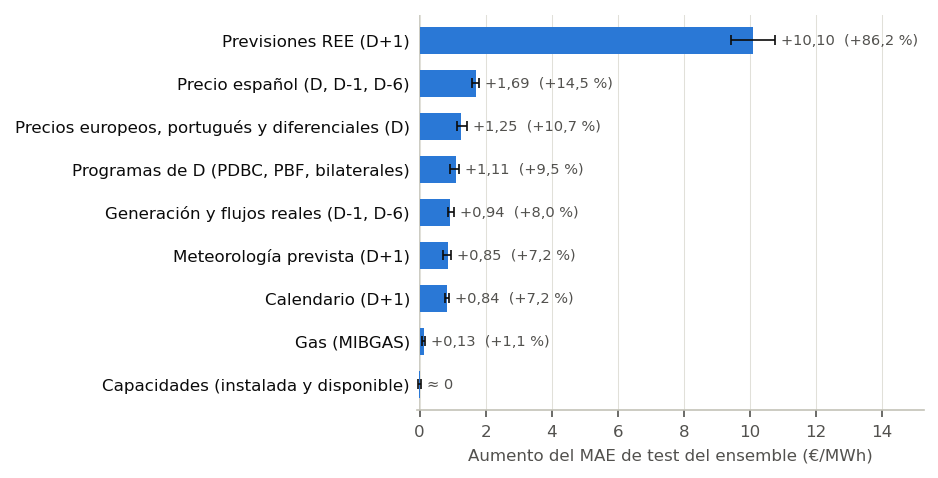

In [4]:
TINTA, TINTA_2, EJE, REJILLA = "#0b0b0b", "#52514e", "#c3c2b7", "#e1e0d9"
BARRA = "#2a78d6"
SIN_EFECTO = {"capacidades"}          # efecto no medible: se rotula "≈ 0"

with estilo_de_script():
    tabla = perm[perm.variante == "principal"].sort_values("aumento_MAE_media", ascending=True)
    ypos = np.arange(len(tabla), dtype=float)

    plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 8,
                         "axes.edgecolor": EJE, "axes.labelcolor": TINTA_2,
                         "xtick.color": TINTA_2, "ytick.color": TINTA})
    fig, ax = plt.subplots(figsize=(16 / 2.54, 0.55 + 0.3 * len(ypos)), dpi=300)
    xmax = float(tabla.aumento_MAE_max.max()) * 1.42

    for y0, g, m, a, b, pct in zip(ypos, tabla.grupo, tabla.aumento_MAE_media,
                                   tabla.aumento_MAE_min, tabla.aumento_MAE_max,
                                   tabla["aumento_%_media"]):
        ax.barh(y0, m, height=0.62, color=BARRA, edgecolor="none", zorder=2)
        ax.errorbar(m, y0, xerr=[[m - a], [b - m]], fmt="none", ecolor=TINTA,
                    elinewidth=0.8, capsize=2.2, capthick=0.8, zorder=4)
        txt = "≈ 0" if g in SIN_EFECTO else coma(f"{m:+.2f}  ({pct:+.1f} %)")
        ax.text(max(b, 0) + xmax * 0.012, y0, txt, va="center", ha="left",
                fontsize=7, color=TINTA_2)

    ax.set_yticks(ypos, [ETIQUETAS.get(g, g) for g in tabla.grupo])
    ax.axvline(0, color=EJE, linewidth=0.8, zorder=1)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: coma(f"{v:g}")))
    ax.set_xlim(min(0, float(tabla.aumento_MAE_min.min()) * 1.2), xmax)
    ax.set_ylim(ypos[0] - 0.6, ypos[-1] + 0.6)
    ax.set_xlabel("Aumento del MAE de test del ensemble (€/MWh)")
    ax.grid(axis="x", color=REJILLA, linewidth=0.5, zorder=0)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.tick_params(axis="y", length=0)
    fig.tight_layout()
    comparar_con_informe(fig, INT / "fig_permutacion_ensemble.png", dpi=300, facecolor="white")
    mostrar(fig)

### 1.2 · El mismo ejercicio en cada miembro

Aumento del MAE de test de cada miembro con la misma permutación (columnas ordenadas por peso). Sirve para ver de dónde sale cada barra:

- las previsiones REE pesan en casi todos los miembros;
- el precio español y los precios europeos, sobre todo en LightGBM;
- el calendario, en la GRU y los seq2seq.

Las dos últimas columnas comparan la media ponderada de los aumentos de los miembros con el aumento del ensemble. En el precio español y en los europeos el aumento del ensemble es muy inferior porque los errores de los miembros se compensan al combinarse. En otros grupos, como las previsiones REE, no hay tal compensación.

In [5]:
miem = pd.read_csv(INT / "permutacion_ensemble_miembros.csv")
orden_grupos = list(principal.grupo)
piv = (miem[miem.grupo.isin(orden_grupos)]
       .pivot(index="grupo", columns="modelo", values="aumento_MAE_media")
       .reindex(index=orden_grupos, columns=list(PESOS)))
ponderada = (piv * pd.Series({k: PESOS[k] / 30 for k in PESOS})).sum(axis=1)
piv.columns = [f"{m} ({PESOS[m]}/30)" for m in piv.columns]
piv["media ponderada de miembros"] = ponderada
piv["ensemble"] = f.loc[orden_grupos, "aumento_MAE_media"]
piv.index = [ETIQUETAS[g] for g in piv.index]
display(piv.round(2))
print("MAE base de test por miembro (€/MWh):",
      ", ".join(coma(f"{m} {v:.2f}") for m, v in miem.groupby("modelo").MAE_base.first().reindex(list(PESOS)).items()))

,lgbm_nucleo__s1 (11/30),denso__s2 (10/30),lstm__s1 (3/30),seq2seq_absoluto__s2 (3/30),gru__s2 (2/30),seq2seq__s1 (1/30),media ponderada de miembros,ensemble
Previsiones REE (D+1),12.50,10.31,9.43,5.00,2.54,2.59,9.72,10.10
"Precio español (D, D-1, D-6)",10.46,3.80,1.61,3.26,0.65,0.44,5.65,1.69
"Precios europeos, portugués y diferenciales (D)",6.42,2.49,3.89,3.08,1.60,1.46,4.04,1.25
"Programas de D (PDBC, PBF, bilaterales)",3.10,0.97,0.53,1.15,2.16,1.06,1.81,1.11
"Generación y flujos reales (D-1, D-6)",0.87,1.21,0.36,2.00,0.58,0.65,1.02,0.94
Meteorología prevista (D+1),0.34,1.24,0.79,2.60,1.31,1.20,1.00,0.85
Calendario (D+1),1.15,0.07,0.22,1.34,2.59,2.31,0.85,0.84
Gas (MIBGAS),-0.05,0.01,0.02,0.23,0.02,0.00,0.01,0.13
Capacidades (instalada y disponible),-0.14,0.03,0.32,0.22,0.11,-0.01,0.02,-0.00


MAE base de test por miembro (€/MWh): lgbm_nucleo__s1 14,16, denso__s2 13,47, lstm__s1 15,78, seq2seq_absoluto__s2 15,28, gru__s2 12,89, seq2seq__s1 13,28


### 1.3 · Cómo leer el precio de D

El +1,69 del precio español **no mide la dependencia del sistema respecto al precio de D**. El precio portugués y los diferenciales siguen intactos en su grupo y reconstruyen el español, y los errores de los miembros se compensan. Si se permuta también el ancla del residuo, las redes residuales vuelven a precio sumando un precio de otro día y el ensemble se dispara. LightGBM y `seq2seq_absoluto`, que predicen precio, no cambian entre ambas variantes.

In [6]:
anc = perm.set_index("grupo").loc["precio_es__ancla_permutada"]
lectura = (miem[miem.grupo.isin(["precio_es", "precio_es__ancla_permutada"])]
           .pivot(index="modelo", columns="grupo", values="aumento_MAE_media")
           .reindex(list(PESOS)).rename(columns={"precio_es": "ancla fija",
                                                "precio_es__ancla_permutada": "ancla permutada"}))
lectura.insert(0, "objetivo", pd.Series(OBJETIVO))
lectura.loc["ensemble"] = ["media ponderada de los seis", f.loc["precio_es", "aumento_MAE_media"],
                           anc.aumento_MAE_media]
display(lectura.round(2))
print(coma(f"precio español con el ancla permutada: {anc.aumento_MAE_media:+.4f} €/MWh "
      f"(rango {anc.aumento_MAE_min:+.2f} a {anc.aumento_MAE_max:+.2f}; {anc['aumento_%_media']:+.1f} %)"))
cifra("1", "precio español con el ancla permutada (€/MWh)", anc.aumento_MAE_media)

grupo,objetivo,ancla fija,ancla permutada
modelo,,,
lgbm_nucleo__s1,precio,10.46,10.46
denso__s2,residuo frente a D,3.80,28.67
lstm__s1,residuo frente a D,1.61,29.80
seq2seq_absoluto__s2,precio,3.26,3.26
gru__s2,residuo frente a D,0.65,33.73
seq2seq__s1,residuo frente a D,0.44,33.70
ensemble,media ponderada de los seis,1.69,20.36


precio español con el ancla permutada: +20,3556 €/MWh (rango +19,55 a +20,78; +173,6 %)
  precio español con el ancla permutada (€/MWh)                                   20,36   en el informe


## 2 · El miembro de mayor peso: LightGBM con SHAP

TreeSHAP exacto (`pred_contrib=True` del booster de `lgbm_nucleo__s1`) sobre las filas horarias de test, validación y entrenamiento. El SHAP de una variable es cuánto desplaza esa fila la predicción respecto al valor esperado del modelo. El |SHAP| medio por grupo es la suma de los |SHAP| medios de sus variables, y la proporción la reparte sobre el total.

**Cómo leerlo**: es la importancia *para LightGBM* (11/30 del ensemble), no para el sistema. Aun así sus cuatro primeros grupos son los cuatro primeros de la permutación del ensemble. La proporción en validación sirve para ver si el reparto es estable.

In [7]:
recalcular("shap_lgbm.py", "shap_lgbm_ganancia.py")
res = json.loads((INT / "shap_lgbm_resumen.json").read_text(encoding="utf-8"))
grp = pd.read_csv(INT / "shap_lgbm_grupos.csv", index_col=0)
var = pd.read_csv(INT / "shap_lgbm_variables.csv", index_col=0)

print(f"{res['modelo']}: " + coma(f"{res['n_features']} variables, {res['n_arboles']} árboles; MAE test {res['test_MAE']:.4f} "
      f"({res['test_dias']} días), MAE val {res['val_MAE']:.4f}; error máximo de aditividad SHAP en test "
      f"{res['test_shap_aditividad_max_err']:.1e}"))
t2 = grp[["n_variables", "variable_principal", "shap_abs_test", "proporcion_test", "proporcion_val",
          "proporcion_train", "proporcion_ganancia"]].copy()
t2["n_variables"] = t2.n_variables.astype(int)
display(t2.round(3))

rehecha = var.groupby("grupo").shap_abs_medio_test.sum() / var.shap_abs_medio_test.sum()
assert np.allclose(rehecha.reindex(grp.index), grp.proporcion_test, atol=1e-5)
print("proporciones de test rehechas desde shap_lgbm_variables.csv: coinciden")
print(coma(f"correlación de rangos del |SHAP| por variable, validación frente a test: {res['spearman_rango_shap_val_vs_test']:.3f}"))
cifra("2", "peso de LightGBM en el ensemble", f"{PESOS['lgbm_nucleo__s1']}/30")
for g in grp.index[:4]:
    cifra("2", f"{g}: proporción de |SHAP| en test (%)", 100 * grp.loc[g, "proporcion_test"], dec=1)

MAPA = {"Previsiones REE (demanda, eólica, solar)": "prev_ree", "Precio español (D, D-1, D-6)": "precio_es",
        "Precios europeos D y diferenciales": "precios_europeos", "Programas PDBC/PBF de D": "programas_D"}
print("los cuatro primeros grupos por SHAP son los cuatro primeros de la permutación:",
      {MAPA.get(g) for g in grp.index[:4]} == set(principal.grupo[:4]))

RECALCULAR = False: se leen los resultados guardados en docs\interpretabilidad
lgbm_nucleo__s1: 112 variables, 1900 árboles; MAE test 14,1643 (212 días), MAE val 13,0082; error máximo de aditividad SHAP en test 1,5e-12


,n_variables,variable_principal,shap_abs_test,proporcion_test,proporcion_val,proporcion_train,proporcion_ganancia
grupo,,,,,,,
"Previsiones REE (demanda, eólica, solar)",3,ree_gwind_prev,30.632,0.255,0.243,0.194,0.043
"Precio español (D, D-1, D-6)",3,es_esios_D,22.873,0.191,0.201,0.232,0.341
Precios europeos D y diferenciales,8,pt_entsoe_D,21.839,0.182,0.187,0.241,0.518
Programas PDBC/PBF de D,30,pdbc_wind_mw_D,15.335,0.128,0.131,0.111,0.028
"Generación, demanda y flujos reales D-1/D-6",39,ree_gcoal_mw_Dm6,12.418,0.103,0.107,0.082,0.027
Calendario y hora,13,d1_dow,4.876,0.041,0.046,0.041,0.013
Gas MIBGAS,1,gas_mibgas,4.499,0.037,0.022,0.040,0.011
Meteorología prevista,6,wind100_meteo,4.374,0.036,0.033,0.034,0.011
Capacidades (disponible e instalada),9,capdisp_nuclear_mw,3.185,0.027,0.030,0.026,0.008


proporciones de test rehechas desde shap_lgbm_variables.csv: coinciden
correlación de rangos del |SHAP| por variable, validación frente a test: 0,979
  peso de LightGBM en el ensemble                                                 11/30   en el informe
  Previsiones REE (demanda, eólica, solar): proporción de |SHAP| en test (%)                   25,5   en el informe
  Precio español (D, D-1, D-6): proporción de |SHAP| en test (%)                   19,1   en el informe
  Precios europeos D y diferenciales: proporción de |SHAP| en test (%)                   18,2   en el informe
  Programas PDBC/PBF de D: proporción de |SHAP| en test (%)                        12,8   en el informe
los cuatro primeros grupos por SHAP son los cuatro primeros de la permutación: True


In [8]:
t2v = var.nsmallest(15, "rango_test")[["grupo", "shap_abs_medio_test", "shap_medio_test", "proporcion_test",
                                        "rango_test", "rango_val", "rango_train", "rango_ganancia"]]
display(t2v.round(3))
print(coma(f"primera variable: {t2v.index[0]} ({t2v.shap_abs_medio_test.iloc[0]:.2f} €/MWh de |SHAP| medio) frente a "
      f"es_esios_D ({var.loc['es_esios_D', 'shap_abs_medio_test']:.2f}, puesto {var.loc['es_esios_D', 'rango_test']})"))

,grupo,shap_abs_medio_test,shap_medio_test,proporcion_test,rango_test,rango_val,rango_train,rango_ganancia
variable,,,,,,,,
pt_entsoe_D,Precios europeos D y diferenciales,19.104,-13.163,0.159,1,1,1,1
ree_gwind_prev,"Previsiones REE (demanda, eólica, solar)",14.577,-2.690,0.121,2,2,3,5
es_esios_D,"Precio español (D, D-1, D-6)",12.129,-6.380,0.101,3,3,2,2
ree_gsolar_prev,"Previsiones REE (demanda, eólica, solar)",10.183,-5.988,0.085,4,4,7,11
es_esios_Dm6,"Precio español (D, D-1, D-6)",7.303,-2.239,0.061,5,5,4,4
ree_demanda_prev,"Previsiones REE (demanda, eólica, solar)",5.872,1.409,0.049,6,6,5,7
gas_mibgas,Gas MIBGAS,4.499,3.585,0.037,7,10,8,6
pdbc_wind_mw_D,Programas PDBC/PBF de D,4.389,1.343,0.037,8,7,9,8
es_esios_Dm1,"Precio español (D, D-1, D-6)",3.441,-2.423,0.029,9,8,6,3


primera variable: pt_entsoe_D (19,10 €/MWh de |SHAP| medio) frente a es_esios_D (12,13, puesto 3)


### 2.1 · Figura de apoyo

Mismo código que `fig_shap_lgbm.py`: (a) proporción de |SHAP| medio en test por grupo; (b) las doce variables con mayor |SHAP| medio, con el color de su grupo. No entró en el informe, que resume estas cifras en el texto, pero ayuda a leer las tablas de arriba. Se compara con `fig_shap_lgbm.png`.

fig_shap_lgbm.png: 2040x883 px, píxeles distintos 0,000 % -> idéntica a la del informe


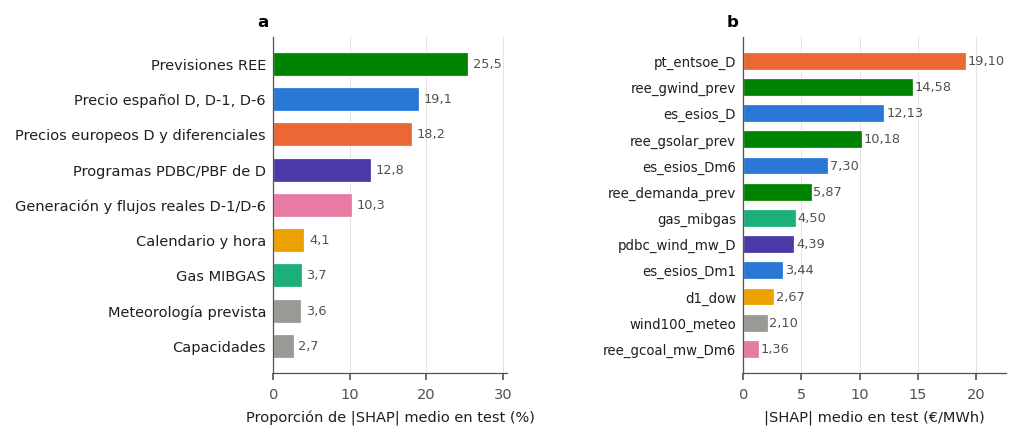

In [9]:
K = 12
CM = 1 / 2.54
COLOR = {
    "Precio español (D, D-1, D-6)": "#2a78d6",
    "Precios europeos D y diferenciales": "#eb6834",
    "Gas MIBGAS": "#1baf7a",
    "Calendario y hora": "#eda100",
    "Programas PDBC/PBF de D": "#4a3aa7",
    "Generación, demanda y flujos reales D-1/D-6": "#e87ba4",
    "Previsiones REE (demanda, eólica, solar)": "#008300",
    "Meteorología prevista": "#9a9994",
    "Capacidades (disponible e instalada)": "#9a9994",
    "Otros": "#9a9994",
}
CORTO = {
    "Precio español (D, D-1, D-6)": "Precio español D, D-1, D-6",
    "Precios europeos D y diferenciales": "Precios europeos D y diferenciales",
    "Previsiones REE (demanda, eólica, solar)": "Previsiones REE",
    "Meteorología prevista": "Meteorología prevista",
    "Gas MIBGAS": "Gas MIBGAS",
    "Calendario y hora": "Calendario y hora",
    "Programas PDBC/PBF de D": "Programas PDBC/PBF de D",
    "Generación, demanda y flujos reales D-1/D-6": "Generación y flujos reales D-1/D-6",
    "Capacidades (disponible e instalada)": "Capacidades",
    "Otros": "Otros",
}
TINTA_S, TINTA2_S, REJILLA_S = "#1f1f1e", "#52514e", "#e4e3df"

with estilo_de_script():
    v, g = var, grp
    plt.rcParams.update({"font.size": 7, "font.family": "DejaVu Sans", "axes.edgecolor": TINTA2_S,
                         "axes.labelcolor": TINTA_S, "xtick.color": TINTA2_S, "ytick.color": TINTA_S,
                         "axes.linewidth": 0.6})
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(16 * CM, 7.4 * CM),
                                 gridspec_kw={"width_ratios": [1, 1.12], "wspace": 0.95})

    gg = g.sort_values("proporcion_test")
    y = range(len(gg))
    a1.barh(y, gg.proporcion_test * 100, height=0.68, color=[COLOR.get(n, "#9a9994") for n in gg.index],
            edgecolor="white", linewidth=0.6)
    a1.set_yticks(list(y), [CORTO.get(n, n) for n in gg.index])
    for i, val in zip(y, gg.proporcion_test * 100):
        a1.text(val + 0.6, i, f"{val:.1f}".replace(".", ","), va="center", fontsize=6.2, color=TINTA2_S)
    a1.set_xlabel("Proporción de |SHAP| medio en test (%)")
    a1.set_xlim(0, gg.proporcion_test.max() * 100 * 1.2)
    a1.text(-0.02, 1.03, "a", transform=a1.transAxes, fontweight="bold", fontsize=8, ha="right")

    top = v.nlargest(K, "shap_abs_medio_test").iloc[::-1]
    y = range(len(top))
    a2.barh(y, top.shap_abs_medio_test, height=0.68, color=[COLOR.get(n, "#9a9994") for n in top.grupo],
            edgecolor="white", linewidth=0.6)
    a2.set_yticks(list(y), list(top.index), fontsize=6.4)
    for i, val in zip(y, top.shap_abs_medio_test):
        a2.text(val + 0.15, i, f"{val:.2f}".replace(".", ","), va="center", fontsize=6.2, color=TINTA2_S)
    a2.set_xlabel("|SHAP| medio en test (€/MWh)")
    a2.set_xlim(0, top.shap_abs_medio_test.max() * 1.18)
    a2.text(-0.02, 1.03, "b", transform=a2.transAxes, fontweight="bold", fontsize=8, ha="right")

    for a in (a1, a2):
        a.spines[["top", "right"]].set_visible(False)
        a.grid(axis="x", color=REJILLA_S, linewidth=0.5)
        a.set_axisbelow(True)
        a.tick_params(axis="y", length=0)
        a.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}".replace(".", ",")))

    comparar_con_informe(fig, INT / "fig_shap_lgbm.png", dpi=300, bbox_inches="tight", facecolor="white")
    mostrar(fig)

### 2.2 · Ganancia frente a SHAP

La importancia por ganancia de LightGBM concentra más de la mitad del modelo en los precios europeos y un tercio en el español. El |SHAP| reparte mucho más. No se contradicen, miden cosas distintas. La ganancia suma la reducción de la pérdida en cada división y favorece a las variables que separan niveles de precio muy distintos. El |SHAP| medio, en cambio, pesa igual cada desplazamiento de la predicción. La columna de SHAP² en entrenamiento pondera más los desplazamientos grandes y queda entre ambas: los dos grupos de precios suman un 74,5 %, frente al 85,9 % de la ganancia y el 47,3 % del |SHAP|. Las columnas por año muestran que el peso de las previsiones REE sube en 2023 y 2024.

In [10]:
gvs = pd.read_csv(INT / "shap_lgbm_ganancia_vs_shap_grupos.csv", index_col=0)
total_fila = gvs.loc[gvs.index.str.startswith("(total")]
gvs = gvs.drop(total_fila.index)
display((100 * gvs[["proporcion_ganancia_3s", "proporcion_abs_shap_train", "proporcion_shap2_train"]
                   + [c for c in gvs.columns if c.startswith("proporcion_abs_shap_20")]]).round(1))
print("|SHAP| total medio por fila en entrenamiento, por año (€/MWh):",
      ", ".join(coma(f"{c[-4:]} {x:.1f}") for c, x in total_fila.dropna(axis=1).iloc[0].items()))
precios = ["Precios europeos D y diferenciales", "Precio español (D, D-1, D-6)"]
print(coma(f"precios europeos + español: ganancia {100 * gvs.loc[precios, 'proporcion_ganancia_3s'].sum():.1f} %, "
      f"SHAP² {100 * gvs.loc[precios, 'proporcion_shap2_train'].sum():.1f} %, "
      f"|SHAP| {100 * gvs.loc[precios, 'proporcion_abs_shap_train'].sum():.1f} % (entrenamiento)"))
print(coma(f"correlación de rangos ganancia frente a |SHAP| por variable: test {res['spearman_rango_ganancia_vs_shap_test']:.3f}, "
      f"entrenamiento {res['spearman_rango_ganancia_vs_shap_train']:.3f}"))
sem = pd.read_csv(INT / "shap_lgbm_ganancia_semillas.csv")
display(sem.pivot(index="variable", columns="modelo", values="proporcion_ganancia").round(3))

,proporcion_ganancia_3s,proporcion_abs_shap_train,proporcion_shap2_train,proporcion_abs_shap_2020,proporcion_abs_shap_2021,proporcion_abs_shap_2022,proporcion_abs_shap_2023,proporcion_abs_shap_2024
grupo,,,,,,,,
Precios europeos D y diferenciales,51.8,24.1,50.0,28.4,26.8,26.5,17.1,20.4
"Precio español (D, D-1, D-6)",34.1,23.2,24.5,29.9,23.4,24.1,17.6,20.6
"Previsiones REE (demanda, eólica, solar)",4.3,19.4,19.5,14.0,17.3,16.6,26.9,24.1
Programas PDBC/PBF de D,2.8,11.1,2.2,8.5,10.4,10.6,13.9,12.3
"Generación, demanda y flujos reales D-1/D-6",2.7,8.2,0.5,6.6,7.5,7.7,9.7,9.5
Calendario y hora,1.3,4.1,0.8,3.2,3.7,3.8,5.2,4.6
Meteorología prevista,1.1,3.4,0.4,2.7,3.4,3.0,4.3,3.7
Gas MIBGAS,1.1,4.0,1.9,4.8,4.7,5.0,2.6,2.3
Capacidades (disponible e instalada),0.8,2.6,0.2,1.9,2.8,2.7,2.6,2.6


|SHAP| total medio por fila en entrenamiento, por año (€/MWh): 2020 95,7, 2021 106,6, 2022 144,3, 2023 93,3, 2024 98,6
precios europeos + español: ganancia 85,9 %, SHAP² 74,5 %, |SHAP| 47,3 % (entrenamiento)
correlación de rangos ganancia frente a |SHAP| por variable: test 0,738, entrenamiento 0,843


modelo,lgbm_nucleo__s0,lgbm_nucleo__s1,lgbm_nucleo__s2
variable,,,
es_esios_D,0.227,0.231,0.206
es_esios_Dm1,0.057,0.095,0.029
pt_entsoe_D,0.513,0.454,0.551
spread_es_pt_D,0.000,0.000,0.000


## 3 · Precio portugués frente a español

La primera variable del LightGBM por SHAP es el precio portugués de D, por delante del español. **Esa separación no es interpretable**: los dos casan al mismo precio en la gran mayoría de las horas (mercado ibérico acoplado). Permutar uno solo crea combinaciones portugués-español que casi no existen en entrenamiento, y su aumento mezcla la información perdida con el efecto de esa combinación irreal. La cifra fiable es la de **permutarlos juntos**, que supera la suma de las dos por separado.

Aquí la permutación es por días sobre el MAE de test del propio LightGBM (30 repeticiones), no del ensemble.

In [11]:
pe = res["portugal_espana"]
corr_pt = pd.DataFrame({c: {"horas": pe[c]["horas"], "pearson": pe[c]["pearson"], "spearman": pe[c]["spearman"],
                            "% horas idénticas (±0,01)": pe[c]["pct_identicas_tol_0.01"],
                            "dif. media cuando difieren": pe[c]["dif_abs_media_cuando_difieren"]}
                        for c in ["total", "train", "val", "test"]}).T
corr_pt["horas"] = corr_pt.horas.astype(int)
display(corr_pt.round(3))
print("% de horas idénticas por año:", ", ".join(coma(f"{a} {v:.2f}") for a, v in pe["pct_identicas_por_anio"].items()))
cifra("3", "correlación precio portugués-español de D, 2020-2026", pe["total"]["pearson"], dec=3)

pt = pd.read_csv(INT / "permutacion_pt_es_lgbm_test.csv")
display(pt[["variante", "MAE_base", "MAE_perm_media", "delta_MAE_media", "delta_MAE_p05", "delta_MAE_p95",
            "delta_MAE_pct", "repeticiones"]].round(2))
d = pt.set_index("variante").delta_MAE_media
cifra("3", "LightGBM: permutar portugués y español juntos (€/MWh)", d["pt_entsoe_D + es_esios_D"])
cifra("3", "LightGBM: solo el portugués (€/MWh)", d["pt_entsoe_D"])
cifra("3", "LightGBM: solo el español (€/MWh)", d["es_esios_D"])
print(coma(f"  suma por separado {d['pt_entsoe_D'] + d['es_esios_D']:.2f} < juntos {d['pt_entsoe_D + es_esios_D']:.2f}; "
      f"añadir el diferencial apenas cambia ({d['pt_entsoe_D + es_esios_D + spread_es_pt_D']:.2f})"))
print(coma(f"  proporción de |SHAP| en test: portugués {100 * pe['test_proporcion_shap_pt']:.1f} %, español "
      f"{100 * pe['test_proporcion_shap_es']:.1f} %; correlación entre sus SHAP {pe['test_corr_shap_pt_vs_shap_es']:.3f}"))

,horas,pearson,spearman,"% horas idénticas (±0,01)",dif. media cuando difieren
total,57521,0.997,0.994,93.787,12.621
train,43675,0.998,0.995,95.835,14.206
val,8759,0.993,0.989,89.611,11.773
test,5087,0.988,0.985,83.389,10.122


% de horas idénticas por año: 2020 95,87, 2021 97,36, 2022 97,21, 2023 94,73, 2024 94,01, 2025 89,61, 2026 83,39
  correlación precio portugués-español de D, 2020-2026                            0,997   en el informe


,variante,MAE_base,MAE_perm_media,delta_MAE_media,delta_MAE_p05,delta_MAE_p95,delta_MAE_pct,repeticiones
0,pt_entsoe_D,14.16,19.81,5.65,5.22,6.04,39.88,30
1,es_esios_D,14.16,18.73,4.56,4.17,4.99,32.20,30
2,pt_entsoe_D + es_esios_D,14.16,26.55,12.38,11.65,13.05,87.42,30
3,pt_entsoe_D + es_esios_D + spread_es_pt_D,14.16,26.55,12.39,11.64,13.06,87.47,30
4,es_esios_Dm1 (referencia),14.16,14.68,0.51,0.37,0.65,3.63,30
5,gas_mibgas (referencia),14.16,14.22,0.06,-0.17,0.39,0.42,30


  LightGBM: permutar portugués y español juntos (€/MWh)                           12,38   en el informe
  LightGBM: solo el portugués (€/MWh)                                              5,65   en el informe
  LightGBM: solo el español (€/MWh)                                                4,56   en el informe
  suma por separado 10,21 < juntos 12,38; añadir el diferencial apenas cambia (12,39)
  proporción de |SHAP| en test: portugués 15,9 %, español 10,1 %; correlación entre sus SHAP 0,814


## 4 · Contraste con el EDA

¿Anticipaba el análisis exploratorio qué variables iban a importar? Se cruza el |ρ| de Spearman de cada variable con el precio (ranking del EDA) con su |SHAP| medio en test. La correlación de rangos se rehace aquí desde la tabla.

**Cómo leerlo**: una correlación de rangos baja significa que la asociación marginal ordena mal la importancia en el modelo. El caso más claro son las previsiones REE: asociación marginal débil y, sin embargo, entre las primeras por SHAP. Una explicación plausible es que su efecto es condicional (la eólica o la solar prevista importan según la demanda y la hora), pero **no se ha comprobado**.

In [12]:
eda = res["eda"]
sp = pd.read_csv(INT / "shap_vs_eda_spearman.csv")
rho = sp[["abs_rho", "shap_abs_medio_test"]].corr(method="spearman").iloc[0, 1]
assert abs(rho - eda["spearman_abs_rho_vs_shap_test"]) < 1e-9
print(f"variables del modelo en el ranking del EDA: {eda['features_modelo_en_ranking']} "
      f"(fuera: {', '.join(eda['features_modelo_fuera_ranking'])}); comunes entre las 12 primeras: {eda['top12_comunes']}")
cifra("4", "correlación de rangos |rho| EDA frente a |SHAP| de test", rho, dec=3)

display(sp.head(15)[["variable", "grupo", "shap_abs_medio_test", "rango_test", "abs_rho",
                     "rango_eda_en_modelo"]].round(3))
ree = sp[sp.variable.str.startswith("ree_") & sp.variable.str.endswith("_prev")].sort_values("rango_test")
display(ree[["variable", "rango_test", "rango_eda_en_modelo", "rho", "shap_abs_medio_test"]].round(3))
cifra("4", "previsiones REE: puestos por asociación en el EDA",
      f"puestos {ree.rango_eda_en_modelo.min()} a {ree.rango_eda_en_modelo.max()}")
r = list(ree.rango_test)
cifra("4", "previsiones REE: puestos por SHAP", f"{r[0]}, {r[1]} y {r[2]} por SHAP")

display(pd.read_csv(INT / "shap_vs_eda_grupos.csv", index_col=0).round(3))

variables del modelo en el ranking del EDA: 111 (fuera: d1_vispera_festivo); comunes entre las 12 primeras: 5
  correlación de rangos |rho| EDA frente a |SHAP| de test                         0,314   en el informe


,variable,grupo,shap_abs_medio_test,rango_test,abs_rho,rango_eda_en_modelo
0,pt_entsoe_D,Precios europeos D y diferenciales,19.104,1,0.883,1
1,ree_gwind_prev,"Previsiones REE (demanda, eólica, solar)",14.577,2,0.194,42
2,es_esios_D,"Precio español (D, D-1, D-6)",12.129,3,0.883,2
3,ree_gsolar_prev,"Previsiones REE (demanda, eólica, solar)",10.183,4,0.191,43
4,es_esios_Dm6,"Precio español (D, D-1, D-6)",7.303,5,0.800,4
5,ree_demanda_prev,"Previsiones REE (demanda, eólica, solar)",5.872,6,0.226,34
6,gas_mibgas,Gas MIBGAS,4.499,7,0.685,7
7,pdbc_wind_mw_D,Programas PDBC/PBF de D,4.389,8,0.167,49
8,es_esios_Dm1,"Precio español (D, D-1, D-6)",3.441,9,0.813,3
9,d1_dow,Calendario y hora,2.674,10,0.112,62


,variable,rango_test,rango_eda_en_modelo,rho,shap_abs_medio_test
1,ree_gwind_prev,2,42,-0.194,14.577
3,ree_gsolar_prev,4,43,-0.191,10.183
5,ree_demanda_prev,6,34,0.226,5.872


  previsiones REE: puestos por asociación en el EDA                     puestos 34 a 43   en el informe
  previsiones REE: puestos por SHAP                                   2, 4 y 6 por SHAP   en el informe


,abs_rho_max,abs_rho_media,variable_rho_max,proporcion_test,rango_grupo_eda,rango_grupo_shap
grupo,,,,,,
Precios europeos D y diferenciales,0.883,0.488,pt_entsoe_D,0.182,1,3
"Precio español (D, D-1, D-6)",0.883,0.832,es_esios_D,0.191,2,2
Gas MIBGAS,0.685,0.685,gas_mibgas,0.038,3,7
Programas PDBC/PBF de D,0.499,0.196,pdbc_ccgt_mw_D,0.128,4,4
"Generación, demanda y flujos reales D-1/D-6",0.462,0.165,ree_gccgas_mw_Dm1,0.104,5,5
Meteorología prevista,0.234,0.112,wind100_meteo,0.036,6,8
"Previsiones REE (demanda, eólica, solar)",0.226,0.203,ree_demanda_prev,0.255,7,1
Calendario y hora,0.221,0.100,d1_regimen_tope_gas,0.041,8,6
Capacidades (disponible e instalada),0.196,0.071,capdisp_hydro_mw,0.026,9,9


## 5 · Comportamiento: cuánto se aparta el ensemble del precio de D

Aquí no se explican variables sino la **forma de la salida**, comparada con la persistencia (D+1 = D, con D el `ref_test_naive` del pipeline).

- **forma_vs_D**: correlación media del perfil horario sin nivel con el de D. Si el ensemble correlaciona con D más que la realidad, se queda cerca de la forma de ayer.
- **movimiento_%**: magnitud media de lo que se mueve respecto a D, en % de lo que se mueve el real. Por debajo de 100, la predicción encoge el cambio.
- **amplificación**: D + a·(pred − D), con *a* ajustado en validación. Si el encogimiento fuera un sesgo corregible, mejoraría el test.
- **cuartiles**: los 212 días de test en cuatro grupos de 53 según el cambio real medio |D+1 − D|. Por construcción, ese cambio es el MAE de la persistencia en cada día, de modo que el patrón por cuartiles es en buena parte consecuencia de la definición.

In [13]:
recalcular("comportamiento.py")
comp = json.loads((INT / "comportamiento.json").read_text(encoding="utf-8"))

orden = ["realidad", "persistencia", "ensemble_seleccion", *PESOS]
copia_t = pd.DataFrame(comp["copia"]["test"]).T.reindex(orden)[
    ["peso", "MAE", "forma_vs_D", "movimiento_%", "corr_cambio", "pendiente_cambio"]]
display(copia_t.round(3))
e, rl = comp["copia"]["test"]["ensemble_seleccion"], comp["copia"]["test"]["realidad"]
cifra("5", "forma del ensemble frente a D (correlación)", e["forma_vs_D"], dec=3)
cifra("5", "forma del real frente a D (correlación)", rl["forma_vs_D"], dec=3)
cifra("5", "movimiento del ensemble (% del cambio real)", e["movimiento_%"], dec=1)

amp = comp["amplificacion"]
print(coma(f"\namplificación: a ajustado en validación = {amp['a_ajustado_val']:.4f} "
      f"(validación {amp['MAE_val_antes']:.2f} -> {amp['MAE_val_despues']:.2f}); "
      f"a óptimo a posteriori en test {amp['a_oraculo_test (solo referencia, no aplicable)']:.4f}, solo referencia"))
cifra("5", "MAE de test antes -> después de amplificar (€/MWh)",
      coma(f"{amp['MAE_test_antes']:.2f} a {amp['MAE_test_despues']:.2f}"))
display(pd.DataFrame({"MAE val": amp["barrido_val"], "MAE test": amp["barrido_test"]}).T.round(2))

RECALCULAR = False: se leen los resultados guardados en docs\interpretabilidad


,peso,MAE,forma_vs_D,movimiento_%,corr_cambio,pendiente_cambio
realidad,NaN,0.000,0.858,100.000,1.000,1.000
persistencia,NaN,16.721,1.000,0.000,NaN,0.000
ensemble_seleccion,NaN,11.724,0.938,82.552,0.789,0.585
lgbm_nucleo__s1,0.367,14.164,0.886,110.755,0.723,0.708
denso__s2,0.333,13.466,0.956,75.793,0.725,0.498
lstm__s1,0.100,15.778,0.919,99.632,0.701,0.559
seq2seq_absoluto__s2,0.100,15.276,0.901,102.420,0.678,0.578
gru__s2,0.067,12.886,0.943,73.288,0.711,0.473
seq2seq__s1,0.033,13.277,0.949,70.406,0.684,0.429


  forma del ensemble frente a D (correlación)                                     0,938   en el informe
  forma del real frente a D (correlación)                                         0,858   en el informe
  movimiento del ensemble (% del cambio real)                                      82,6   en el informe

amplificación: a ajustado en validación = 1,1377 (validación 11,73 -> 11,64); a óptimo a posteriori en test 1,0527, solo referencia
  MAE de test antes -> después de amplificar (€/MWh)                      11,72 a 11,97   en el informe


,0.80,0.85,0.90,0.95,1.00,1.05,1.10,1.15,1.20,1.25,1.30,1.35,1.40
MAE val,12.48,12.24,12.02,11.85,11.73,11.65,11.63,11.65,11.71,11.84,12.01,12.24,12.52
MAE test,11.84,11.76,11.71,11.70,11.72,11.78,11.87,12.00,12.16,12.35,12.56,12.81,13.09


In [14]:
# Recalculo ligero desde las predicciones guardadas, con las mismas fórmulas que comportamiento.py
DIAS = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]
Y, D, E = real.values, leer_pred("ref_test_naive").values, ens.values
cambio = np.abs(Y - D).mean(1)
q = pd.qcut(cambio, 4, labels=["Q1", "Q2", "Q3", "Q4"])
lim = np.quantile(cambio, [0, .25, .5, .75, 1])
mae_e, mae_n = np.abs(E - Y).mean(1), np.abs(D - Y).mean(1)
cq = []
for i, g in enumerate(["Q1", "Q2", "Q3", "Q4"]):
    m = np.asarray(q == g)
    cq.append({"cuartil": g, "n_dias": int(m.sum()), "cambio_min": float(lim[i]), "cambio_max": float(lim[i + 1]),
               "MAE_ensemble": float(mae_e[m].mean()), "MAE_persistencia": float(mae_n[m].mean()),
               "mejora_vs_persistencia_%": float(100 * (mae_e[m].mean() / mae_n[m].mean() - 1))})
guardado = pd.DataFrame(comp["cuartiles_cambio"]["test"]).set_index("cuartil")
rehecho = pd.DataFrame(cq).set_index("cuartil")
assert np.allclose(rehecho, guardado[rehecho.columns], atol=1e-3)
print("cuartiles rehechos desde las predicciones: coinciden con comportamiento.json")
display(guardado[["n_dias", "cambio_min", "cambio_max", "MAE_persistencia", "MAE_ensemble",
                  "mejora_vs_persistencia_%", "dias_ensemble_peor_%", "captura_ensemble_%",
                  "captura_persistencia_%", "pico1h_ensemble_%", "pico1h_persistencia_%"]].round(2))

q1, q4 = guardado.loc["Q1"], guardado.loc["Q4"]
cifra("5", "días por cuartil", f"{int(q1.n_dias)} días por cuartil")
cifra("5", "Q1: MAE del ensemble (€/MWh)", q1.MAE_ensemble)
cifra("5", "Q1: MAE de la persistencia (€/MWh)", q1.MAE_persistencia)
cifra("5", "Q4: reducción del error frente a la persistencia (%)", -q4["mejora_vs_persistencia_%"], dec=1)
cifra("5", "Q4: MAE del ensemble (€/MWh)", q4.MAE_ensemble)
cifra("5", "Q4: MAE de la persistencia (€/MWh)", q4.MAE_persistencia)

dia = comp["dia_ilustrativo"]
fecha = pd.Timestamp(dia["fecha_D+1"])
i_dia = real.index.get_loc(fecha)
print(f"\ndía ilustrativo: {dia['criterio']}")
print(coma(f"  {fecha:%d/%m/%Y} ({DIAS[fecha.dayofweek]}): cociente {mae_e[i_dia] / mae_n[i_dia]:.4f}, "
      f"mediana del cociente en Q4 {dia['cociente_mediano_Q4']:.4f}"))
cifra("5", "fecha del día ilustrativo", f"{fecha:%d/%m/%Y}")
cifra("5", "día ilustrativo: MAE del ensemble (€/MWh)", mae_e[i_dia])
cifra("5", "día ilustrativo: MAE de la persistencia (€/MWh)", mae_n[i_dia])

cuartiles rehechos desde las predicciones: coinciden con comportamiento.json


,n_dias,cambio_min,cambio_max,MAE_persistencia,MAE_ensemble,mejora_vs_persistencia_%,dias_ensemble_peor_%,captura_ensemble_%,captura_persistencia_%,pico1h_ensemble_%,pico1h_persistencia_%
cuartil,,,,,,,,,,,
Q1,53,1.39,9.69,6.37,8.30,30.25,77.36,94.98,92.19,79.25,75.47
Q2,53,9.69,15.08,12.10,10.05,-16.89,32.08,95.44,89.34,83.02,73.58
Q3,53,15.08,22.24,18.33,12.23,-33.28,7.55,90.40,81.19,67.92,58.49
Q4,53,22.24,52.95,30.09,16.31,-45.79,5.66,89.46,81.86,75.47,62.26


  días por cuartil                                                  53 días por cuartil   en el informe
  Q1: MAE del ensemble (€/MWh)                                                     8,30   en el informe
  Q1: MAE de la persistencia (€/MWh)                                               6,37   en el informe
  Q4: reducción del error frente a la persistencia (%)                             45,8   en el informe
  Q4: MAE del ensemble (€/MWh)                                                    16,31   en el informe
  Q4: MAE de la persistencia (€/MWh)                                              30,09   en el informe

día ilustrativo: dia de test del cuartil Q4 de cambio real cuyo cociente MAE_ensemble/MAE_persistencia es el mas cercano a la mediana de ese cociente en Q4
  23/03/2026 (lunes): cociente 0,5074, mediana del cociente en Q4 0,5074
  fecha del día ilustrativo                                                  23/03/2026   en el informe
  día ilustrativo: MAE del ensemble (€/MWh

### 5.1 · Figura del informe (Figura Y)

Mismo código de dibujo que `comportamiento.py`. (a) MAE de test por cuartil de cambio real, persistencia en gris y ensemble en azul; la barra gris es, por construcción, el cambio medio del cuartil. (b) El día de cociente de error mediano del cuartil de mayor cambio: D discontinuo, real en negro y ensemble en azul. En la madrugada y en el pico de la tarde el ensemble queda entre D y el real, que es la imagen del encogimiento del 82,6 % en un día concreto. Se compara con `fig_comportamiento.png`.

fig_comportamiento.png: 1889x850 px, píxeles distintos 0,000 % -> idéntica a la del informe


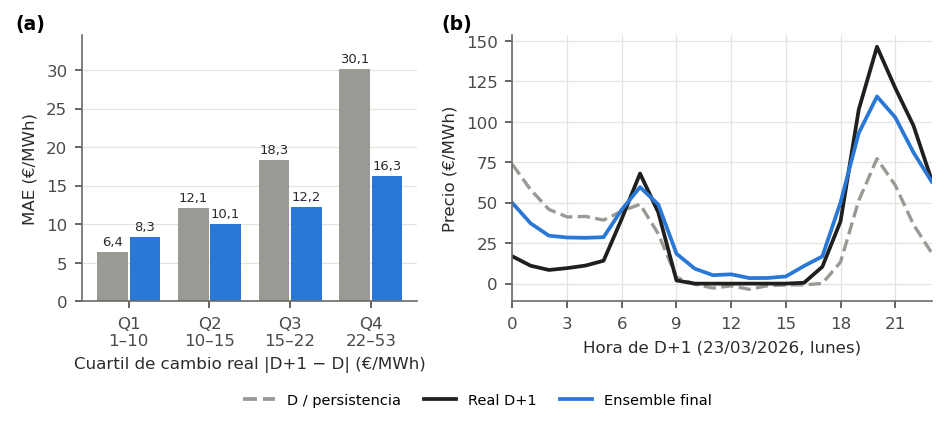

In [15]:
C_ENS, C_PER, C_REAL = "#2a78d6", "#9a9994", "#1f1f1e"

with estilo_de_script():
    plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False,
                         "axes.edgecolor": "#6b6a66", "axes.labelcolor": "#2b2b2a",
                         "xtick.color": "#4a4a48", "ytick.color": "#4a4a48",
                         "legend.frameon": False, "font.family": "DejaVu Sans"})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16 / 2.54, 6.4 / 2.54),
                                   gridspec_kw={"width_ratios": [1, 1.25]})

    x = np.arange(4)
    w = 0.38
    b1 = ax1.bar(x - w / 2 - 0.01, [r["MAE_persistencia"] for r in cq], w, color=C_PER, label="Persistencia (D)")
    b2 = ax1.bar(x + w / 2 + 0.01, [r["MAE_ensemble"] for r in cq], w, color=C_ENS, label="Ensemble final")
    for bars in (b1, b2):
        for b in bars:
            ax1.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5, f"{b.get_height():.1f}".replace(".", ","),
                     ha="center", va="bottom", fontsize=6.3, color="#2b2b2a")
    ax1.set_xticks(x, [f"{r['cuartil']}\n{r['cambio_min']:.0f}–{r['cambio_max']:.0f}" for r in cq])
    ax1.set_xlabel("Cuartil de cambio real |D+1 − D| (€/MWh)")
    ax1.set_ylabel("MAE (€/MWh)")
    ax1.grid(axis="y", color="#e4e3df", lw=0.6)
    ax1.set_axisbelow(True)
    ax1.set_ylim(0, max(r["MAE_persistencia"] for r in cq) * 1.15)
    ax1.text(-0.2, 1.02, "(a)", transform=ax1.transAxes, fontsize=9, fontweight="bold")

    h = np.arange(24)
    ax2.plot(h, D[i_dia], color=C_PER, lw=1.6, ls="--", label="D (persistencia)")
    ax2.plot(h, Y[i_dia], color=C_REAL, lw=1.8, label="Real D+1")
    ax2.plot(h, E[i_dia], color=C_ENS, lw=1.8, label="Ensemble D+1")
    ax2.set_xticks(range(0, 24, 3))
    ax2.set_xlim(0, 23)
    ax2.set_xlabel(f"Hora de D+1 ({fecha.strftime('%d/%m/%Y')}, {DIAS[fecha.dayofweek]})")
    ax2.set_ylabel("Precio (€/MWh)")
    ax2.grid(color="#e4e3df", lw=0.6)
    ax2.set_axisbelow(True)
    fig.legend(handles=[Line2D([], [], color=C_PER, lw=1.8, ls="--", label="D / persistencia"),
                        Line2D([], [], color=C_REAL, lw=1.8, label="Real D+1"),
                        Line2D([], [], color=C_ENS, lw=1.8, label="Ensemble final")],
               loc="lower center", ncol=3, fontsize=7, handlelength=2.2, columnspacing=1.6,
               bbox_to_anchor=(0.5, 0.0))
    ax2.text(-0.17, 1.02, "(b)", transform=ax2.transAxes, fontsize=9, fontweight="bold")

    fig.set_size_inches(16 / 2.54, 7.2 / 2.54)
    fig.tight_layout(w_pad=1.5, rect=(0, 0.07, 1, 1))
    comparar_con_informe(fig, INT / "fig_comportamiento.png", dpi=300)
    mostrar(fig)

## 6 · Consecuencias para el operador y limitaciones

**Para el operador de batería** importa el orden de las horas más que el nivel: comprar en la hora barata y vender en la cara. Dos medidas lo resumen (tabla de abajo): la **captura del spread** (lo que se ganaría operando la hora mínima y máxima *previstas*, en % del spread real del día) y el **acierto del pico a ±1 h**. En ambas el ensemble supera a la persistencia.

Aun así, la selección del ensemble optimiza el MAE. Hay modelos individuales que aciertan más el pico, y un uso de arbitraje justificaría un criterio de selección propio. El operador debe asumir:

- un **cambio previsto más contenido que el real** (82,6 %): en los días de gran cambio, los extremos reales del precio tenderán a ser más pronunciados que los previstos;
- un **error posiblemente mayor en producción**: el histórico de previsiones REE se cargó ya revisado y es el grupo del que más depende el sistema.

**Limitaciones de estas medidas**

- Los grupos correlacionados se compensan (el precio portugués reconstruye el español), así que los aumentos por permutación **no son sumables** ni miden la dependencia aislada.
- Siete meses de test (enero a julio de 2026) **infravaloran las variables lentas**, como el gas o las capacidades, que actúan entre regímenes.
- Ninguna de las medidas es **causal**: describen qué usa el modelo, no qué mueve el precio.

In [16]:
sp_pico = pd.DataFrame(comp["spread_pico"]["test"]).T
display(sp_pico[["n_dias", "captura_ensemble_%", "captura_persistencia_%", "pico1h_ensemble_%",
                 "pico1h_persistencia_%", "MAE_ensemble", "MAE_persistencia", "dias_ensemble_peor_%"]].round(1))
t = comp["spread_pico"]["test"]["todos"]
cifra("6", "captura del spread diario: ensemble (%)", t["captura_ensemble_%"], dec=1)
cifra("6", "pico a ±1 h: ensemble (% de días)", t["pico1h_ensemble_%"], dec=1)
cifra("6", "captura del spread diario: persistencia (%)", t["captura_persistencia_%"], dec=1)
cifra("6", "pico a ±1 h: persistencia (% de días)", t["pico1h_persistencia_%"], dec=1)

,n_dias,captura_ensemble_%,captura_persistencia_%,pico1h_ensemble_%,pico1h_persistencia_%,MAE_ensemble,MAE_persistencia,dias_ensemble_peor_%
todos,212.0,92.6,86.1,76.4,67.5,11.7,16.7,30.7
Q4_cambio,53.0,89.5,81.9,75.5,62.3,16.3,30.1,5.7
top10_cambio,22.0,92.7,87.8,81.8,77.3,18.4,36.6,0.0


  captura del spread diario: ensemble (%)                                          92,6   en el informe
  pico a ±1 h: ensemble (% de días)                                                76,4   en el informe
  captura del spread diario: persistencia (%)                                      86,1   en el informe
  pico a ±1 h: persistencia (% de días)                                            67,5   en el informe


## Resumen de comprobaciones

Todas las cifras impresas arriba, con el texto buscado en `discusion_interpretabilidad_informe.md`, y la comparación píxel a píxel de cada figura con su PNG.

In [17]:
chk = pd.DataFrame(COMPROBACIONES, columns=["sección", "cifra", "texto buscado", "en el informe"])
display(chk)
figs = pd.DataFrame(FIGURAS, columns=["figura", "idéntica al PNG"])
display(figs)
print(f"cifras que aparecen en el informe: {chk['en el informe'].sum()} de {len(chk)}")
print(f"figuras idénticas a su PNG: {figs['idéntica al PNG'].sum()} de {len(figs)}")
assert chk["en el informe"].all() and figs["idéntica al PNG"].all(), \
    "alguna cifra o figura no coincide con el informe"

,sección,cifra,texto buscado,en el informe
0,0,días de test,212 días,True
1,0,MAE de test del ensemble (€/MWh),"11,72",True
2,0,peso del LightGBM en el ensemble,11/30,True
3,1,MAE base del ensemble (€/MWh),"11,72",True
4,1,Previsiones REE: aumento (€/MWh),"10,10",True
5,1,Previsiones REE: aumento (%),"+86,2",True
6,1,"Precio español (D, D-1, D-6) (€/MWh)","+1,69",True
7,1,"Precios europeos, portugués y diferenciales (D) (€/MWh)","+1,25",True
8,1,"Programas de D (PDBC, PBF, bilaterales) (€/MWh)","+1,11",True
9,1,"Generación y flujos reales (D-1, D-6) (€/MWh)","+0,94",True


,figura,idéntica al PNG
0,fig_permutacion_ensemble.png,True
1,fig_shap_lgbm.png,True
2,fig_comportamiento.png,True


cifras que aparecen en el informe: 43 de 43
figuras idénticas a su PNG: 3 de 3
